In [1]:
%matplotlib ipympl
from mpl_interactions import hyperslicer
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
figs = xr.open_zarr(r"C:\Program Files\confocal_control_gui\napari-raman-widget\data\dataset\ds_run_48.zarr")['image']

In [3]:
figs.shape

(1, 1, 1, 2, 1024, 1024)

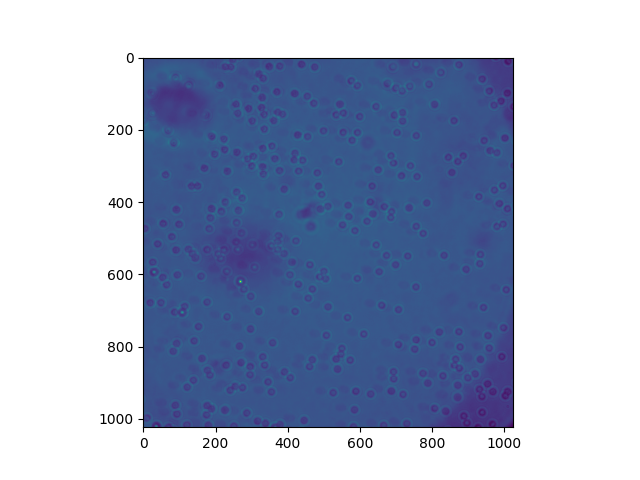

In [4]:
plt.figure()
_ = hyperslicer(figs)

In [5]:
from raman_mda_engine.aiming.autotracking import segment_single_img

import xarray as xr

In [6]:
test = figs[0,0,0,0].values

In [7]:
test

array([[5424, 5440, 5547, ..., 5041, 4624, 3831],
       [5955, 6100, 5991, ..., 5640, 5429, 4707],
       [5899, 6031, 6176, ..., 5667, 5494, 5111],
       ...,
       [6362, 6535, 6536, ..., 2246, 2264, 2176],
       [6367, 6628, 6488, ..., 2183, 2130, 2087],
       [6073, 6155, 6202, ..., 2043, 2035, 1871]], dtype=uint16)

In [9]:
def mask_outside_circle(img, circle_center=None, circle_radius=None):
    height, width = img.shape[-2:]

    if circle_center is None:
        circle_center = (width / 2, height / 2)

    if circle_radius is None:
        circle_radius = min(width, height) / 2

    cx, cy = circle_center
    y, x = np.ogrid[:height, :width]

    mask = (x - cx)**2 + (y - cy)**2 <= circle_radius**2

    return np.where(mask, img, np.min(img))

In [10]:
mask_outside_circle(test, circle_center=(540, 740), circle_radius=400)

array([[1871, 1871, 1871, ..., 1871, 1871, 1871],
       [1871, 1871, 1871, ..., 1871, 1871, 1871],
       [1871, 1871, 1871, ..., 1871, 1871, 1871],
       ...,
       [1871, 1871, 1871, ..., 1871, 1871, 1871],
       [1871, 1871, 1871, ..., 1871, 1871, 1871],
       [1871, 1871, 1871, ..., 1871, 1871, 1871]], dtype=uint16)

In [11]:
img = segment_single_img(test, scale=1, crop=True)

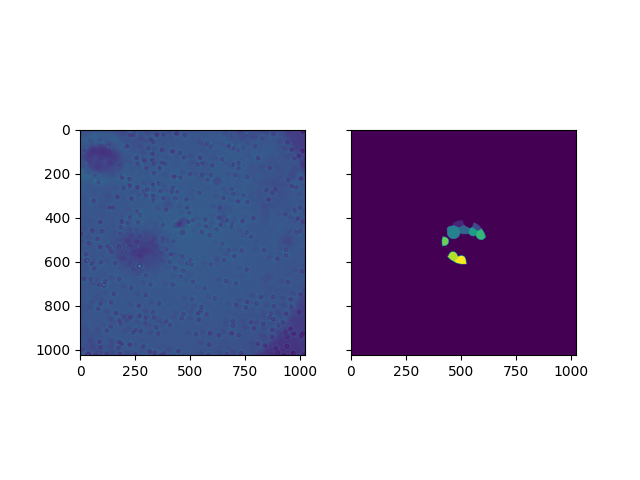

In [12]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
ax[0].imshow(test)
ax[1].imshow(img)

In [26]:
ds = xr.open_zarr('data/dataset/ds_run_19.zarr')

In [33]:
test = ds['image'].values[0,0,0, 0]

In [34]:
test.shape

(1024, 1024)